In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Set =https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [2]:
df=pd.read_csv(r"C:\Users\DEEPA\Downloads\archive\Telco Customer churn\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.shape

(7043, 21)

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Insight
- Only about 16% of customers are senior citizens, so the customer base is largely non-senior.
- Average customer tenure is 32 months, with customers staying anywhere from 0 to 72 months,  indicating a mix of new and long-term customers.
- Monthly charges range from $18.25  to  $ 118.75, showing a wide variety of service plans and customer spending patterns.
- The large variation in both tenure and monthly charges suggests these features may have a significant impact on customer churn.

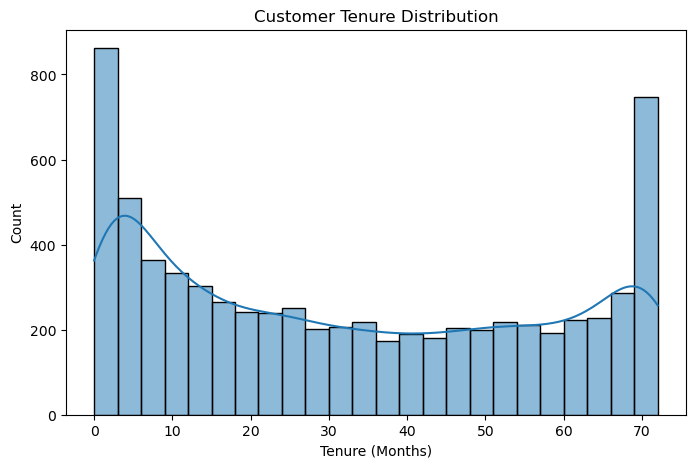

In [8]:
# visuliasing customer tenure distribution
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=24, kde=True)
plt.title('Customer Tenure Distribution')
plt.xlabel('Tenure (Months)')
plt.show()

# Insight -
Customer tenure exhibits a non uniform distribution, with concentration of customers at very low tenure (0-7) months and long tenured customers. This shows some customers are newly acquired and some are long term retained customers.

In [9]:
df.describe(include=object)

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [10]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

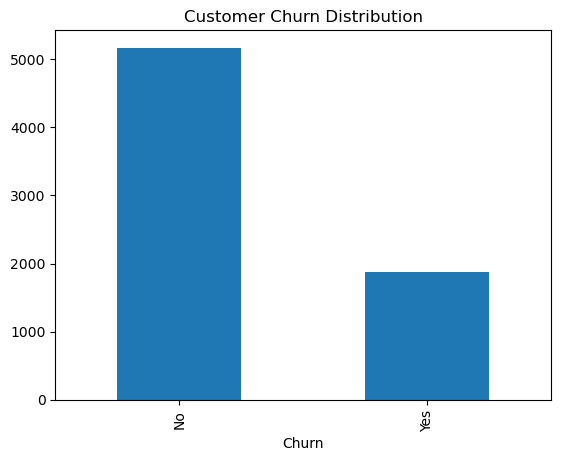

In [11]:
#visulasing churn
df['Churn'].value_counts().plot(kind='bar')
plt.title('Customer Churn Distribution')
plt.show()

### Around 73% of customers stayed with the company whereas 27% churned. Customer attrition remains significant.

In [12]:
#relationship between contract period and churn
crosstab=pd.crosstab(df['Contract'],df['Churn'])
print(crosstab)

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


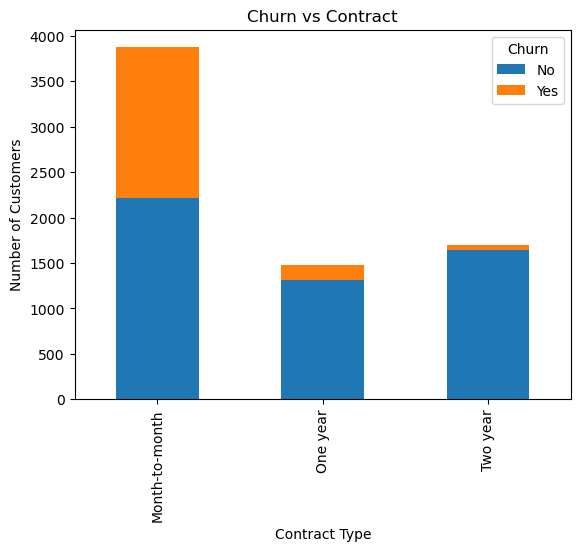

In [13]:
crosstab.plot(kind="bar",stacked=True)
plt.title("Churn vs Contract")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()
           

# Insight:- 
Customers with month-to-month contracts are significantly more likely to churn compared to customers on one-year or two-year contracts. The longer the contract duration, the lower the churn rate, indicating that long-term contracts are associated with higher customer retention.

In [14]:
tenure_pct=pd.crosstab(df["tenure"],
    df["Churn"],
    normalize="index"
) * 100

print(tenure_pct)

Churn           No        Yes
tenure                       
0       100.000000   0.000000
1        38.009788  61.990212
2        48.319328  51.680672
3        53.000000  47.000000
4        52.840909  47.159091
...            ...        ...
68       91.000000   9.000000
69       91.578947   8.421053
70       90.756303   9.243697
71       96.470588   3.529412
72       98.342541   1.657459

[73 rows x 2 columns]


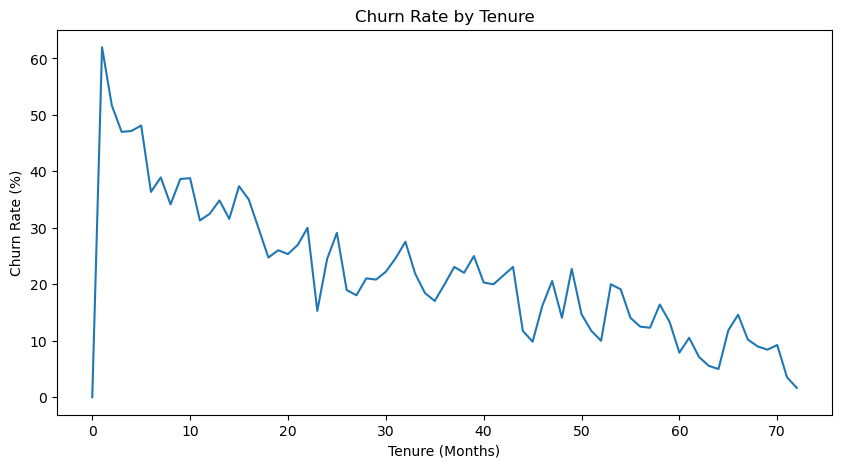

In [15]:
# Understanding the relationship between churn and tenure
tenure_pct["Yes"].plot(figsize=(10,5))

plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")
plt.show()

# Insight-
Churn rates decrease with increasing tenure, suggesting that long-standing customers are more likely to remain with the company than newer customers. This indicates that the company should focus on retaining customers during the early stages of their lifecycle through targeted onboarding, loyalty programs, personalized offers, or other retention initiatives to reduce churn.

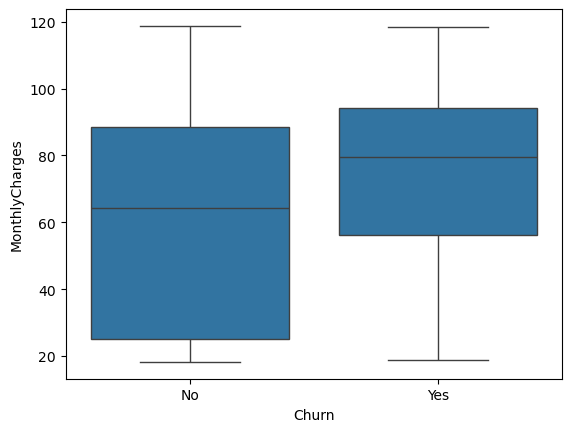

In [16]:
#Churn vs monthly charges
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.show()

# Insight
Higher Monthly charges often correlate with churn

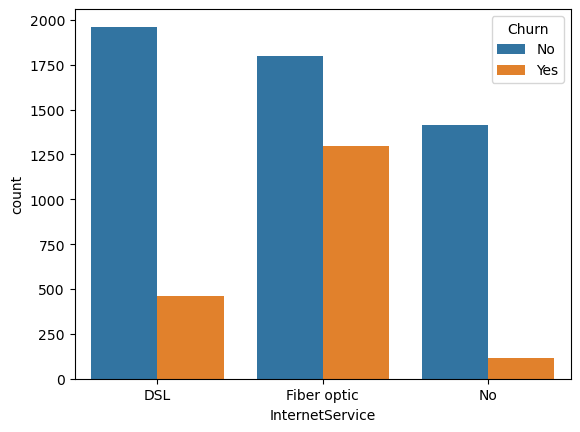

In [17]:
# Visulaise churn vs internet service
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.show()

In [18]:
churn_rate=pd.crosstab(df["Churn"],df["InternetService"],normalize="index")*100

In [19]:
print(churn_rate)

InternetService        DSL  Fiber optic         No
Churn                                             
No               37.920371    34.770004  27.309625
Yes              24.558587    69.395399   6.046014


# Insight
Customers using Fiber Optic internet exhibit the highest churn rate among all internet service categories at 69%. This may indicate dissatisfaction with pricing, service quality, or competitive alternatives. Customers without internet service show the strongest retention.

In [20]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [21]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

### Encoding and scaling the data 


In [22]:
# Create X and y variables
X=df.drop("Churn",axis=1)
y=df["Churn"]

In [23]:
# Encode target variable
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
y=le.fit_transform(y)

In [24]:
print(y[:10])

[0 0 1 0 1 1 0 0 1 0]


In [25]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
#Check number of blanks in Total charges
(X["TotalCharges"] == " ").sum()

np.int64(11)

In [27]:
# Convert to numeric
X["TotalCharges"] = pd.to_numeric(X["TotalCharges"], errors="coerce")

In [28]:
#checking for null
X["TotalCharges"].isnull().sum()

np.int64(11)

In [29]:
#imputing null with median
X["TotalCharges"] = X["TotalCharges"].fillna(X["TotalCharges"].median())

In [30]:
X["TotalCharges"].isnull().sum()

np.int64(0)

In [31]:
#dropping unimp col
X = X.drop("customerID", axis=1)

In [32]:
#encoding 
X = pd.get_dummies(X, drop_first=True)

In [33]:
X.shape

(7043, 30)

In [34]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [35]:
X.dtypes.value_counts()

bool       26
int64       2
float64     2
Name: count, dtype: int64

In [36]:
#converting boolenans to integers
X=X.astype(int,errors="ignore")

# Split data to Train Test

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(5634, 30) (1409, 30) (5634,) (1409,)


In [40]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [41]:
X_train_scaled[:5]

array([[-0.44177295,  0.10237124, -0.51320329, -0.26336773,  0.99433624,
        -0.96923413, -0.65155653, -3.01309011,  3.01309011, -0.85833837,
        -0.88769579, -0.52408075, -0.52408075, -0.63611103, -0.52408075,
        -0.73554636, -0.52408075,  1.37557156, -0.52408075, -0.64327425,
        -0.52408075,  1.25216312, -0.52408075,  1.24796703, -0.51278214,
        -0.56382155, -1.20265302, -0.52380561,  1.40690298, -0.54384572],
       [-0.44177295, -0.71174346,  0.34959033, -0.50484952,  0.99433624,
         1.03174245,  1.53478624,  0.3318852 , -0.3318852 , -0.85833837,
         1.12651205, -0.52408075, -0.52408075,  1.57205259, -0.52408075,
        -0.73554636, -0.52408075, -0.72697054, -0.52408075, -0.64327425,
        -0.52408075, -0.79861799, -0.52408075, -0.80130322, -0.51278214,
        -0.56382155, -1.20265302, -0.52380561, -0.71078107,  1.83875676],
       [-0.44177295, -0.79315493, -0.81186262, -0.75116094,  0.99433624,
         1.03174245,  1.53478624, -3.01309011,  3

### Model Creation and Accuracy

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():

    # Logistic Regression uses scaled data
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

comparison_df = pd.DataFrame(results)

print(comparison_df)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.805536   0.654321  0.566845  0.607450
1        Random Forest  0.789922   0.631757  0.500000  0.558209
2    Gradient Boosting  0.794890   0.643098  0.510695  0.569300


In [43]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [44]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [48]:
print("Accuracy:", accuracy_score(y_test, xgb_pred))


Accuracy: 0.7821149751596878


In [49]:
from sklearn.metrics import confusion_matrix, classification_report

In [50]:
print(confusion_matrix(y_test, xgb_pred))

[[912 123]
 [184 190]]


In [51]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1035
           1       0.61      0.51      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



# Insight
Amongst all the models evaluated, Logistic Regression emerged as the best-performing model, achieving an accuracy of 80.6%, precision of 65.4%, recall of 56.7%, and F1-score of 60.7%.

The model correctly identified 65% of customers predicted to churn (precision) and successfully detected 57% of all actual churners (recall). Compared with Random Forest, Gradient Boosting, and XGBoost, Logistic Regression demonstrated the best balance between identifying churners and minimizing incorrect churn predictions. Therefore, Logistic Regression was selected as the final model for customer churn prediction.

In [53]:
lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [54]:
# Extracting Feature Importance to find out the top churn drivers
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df.sort_values("Abs_Coefficient", ascending=False).head(15)

,Feature,Coefficient,Abs_Coefficient
1,tenure,-1.230331,1.230331
2,MonthlyCharges,-0.821975,0.821975
10,InternetService_Fiber optic,0.736356,0.736356
25,Contract_Two year,-0.589700,0.589700
3,TotalCharges,0.508344,0.508344
24,Contract_One year,-0.285952,0.285952
23,StreamingMovies_Yes,0.242159,0.242159
21,StreamingTV_Yes,0.241368,0.241368
9,MultipleLines_Yes,0.208239,0.208239
26,PaperlessBilling_Yes,0.182152,0.182152


# Top Churn Drivers

In [55]:
coef_df.sort_values("Coefficient", ascending=False).head(10)

,Feature,Coefficient,Abs_Coefficient
10,InternetService_Fiber optic,0.736356,0.736356
3,TotalCharges,0.508344,0.508344
23,StreamingMovies_Yes,0.242159,0.242159
21,StreamingTV_Yes,0.241368,0.241368
9,MultipleLines_Yes,0.208239,0.208239
26,PaperlessBilling_Yes,0.182152,0.182152
28,PaymentMethod_Electronic check,0.181919,0.181919
0,SeniorCitizen,0.052901,0.052901
17,DeviceProtection_Yes,0.045527,0.045527
29,PaymentMethod_Mailed check,0.032773,0.032773


# Top retention Drivers

In [56]:
coef_df.sort_values("Coefficient").head(10)

,Feature,Coefficient,Abs_Coefficient
1,tenure,-1.230331,1.230331
2,MonthlyCharges,-0.821975,0.821975
25,Contract_Two year,-0.589700,0.589700
24,Contract_One year,-0.285952,0.285952
13,OnlineSecurity_Yes,-0.131101,0.131101
19,TechSupport_Yes,-0.108093,0.108093
6,Dependents_Yes,-0.104051,0.104051
18,TechSupport_No internet service,-0.087950,0.087950
11,InternetService_No,-0.087950,0.087950
12,OnlineSecurity_No internet service,-0.087950,0.087950


# Feature Importance Visulisation

In [57]:
feature_imp=coef_df.sort_values("Abs_Coefficient",ascending=False).head()

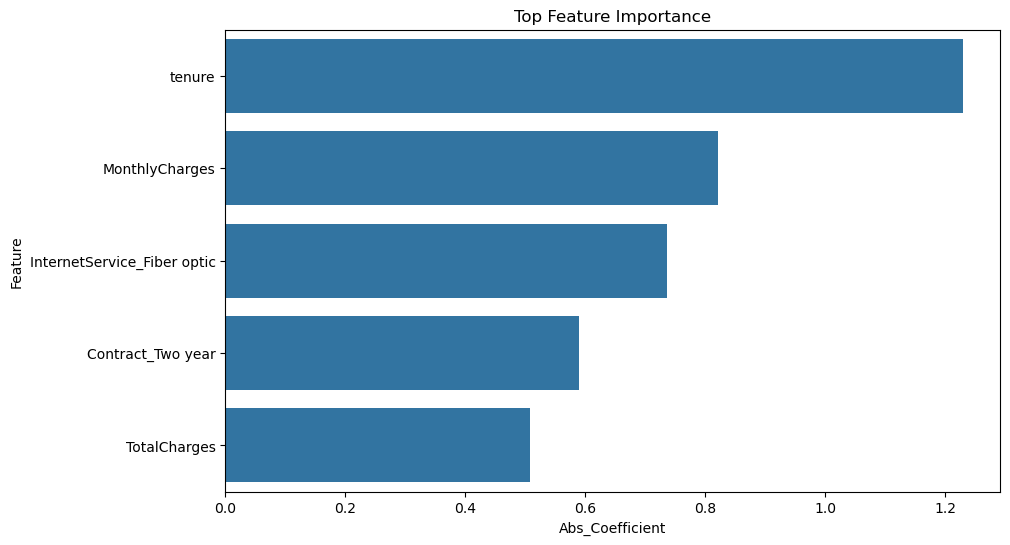

In [60]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_imp,
    x="Abs_Coefficient",
    y="Feature")
plt.title("Top Feature Importance")
plt.show()

# Insight
Feature importance analysis using Logistic Regression coefficients revealed that tenure was the strongest predictor of customer retention. Customers with longer tenure were significantly less likely to churn. Contract type also played a major role, with one-year and two-year contracts reducing the likelihood of churn compared to month-to-month contracts.

Among the factors increasing churn risk, Fiber Optic internet service emerged as the strongest predictor, followed by Total Charges, Streaming Services, Multiple Lines, Paperless Billing, and Electronic Check payment methods. Customers with Online Security and Technical Support services were less likely to churn, indicating that value-added services contribute positively to customer retention.
Also note that exploratory analysis suggested that customers with higher monthly charges were more likely to churn, the Logistic Regression model assigned a negative coefficient to MonthlyCharges after controlling for other variables. This indicates that the relationship between monthly charges and churn is influenced by additional factors such as internet service type, contract duration, and customer tenure.

These findings suggest that customer retention strategies should focus on encouraging long-term contracts, improving support services, and addressing potential concerns among Fiber Optic customers and customers using Electronic Check payment methods.

